In [ ]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.0/121.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2

In [ ]:
import pandas as pd
import mlflow

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/CustomerIntelligence/sample_tickets.csv')
display(df.head())

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [ ]:
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# ---------------------------------------------------------------------
# 1. Feature Engineering Classes/Functions
# ---------------------------------------------------------------------
class TabularEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # Ensure input is a DataFrame
        df = pd.DataFrame(X)
        # Create features based on the column name provided
        desc = df.iloc[:, 0].fillna('')
        char_count = desc.str.len().astype(float)
        word_count = desc.str.split().str.len().astype(float)
        return np.column_stack([char_count, word_count])

def combine_text(df):
    # Ensure we are working on a copy
    df_copy = df.copy()
    df_copy['full_text'] = df_copy['Ticket Subject'].fillna('') + " " + df_copy['Ticket Description'].fillna('')
    return df_copy[['full_text', 'Ticket Description']]

# ---------------------------------------------------------------------
# 2. Pipeline Setup
# ---------------------------------------------------------------------
# Preprocessor handles text and tabular branches separately
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(stop_words='english', max_features=5000), 'full_text'),
        ('tabular', TabularEngineer(), ['Ticket Description'])
    ]
)



In [ ]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,log_loss, roc_auc_score, confusion_matrix, classification_report,make_scorer
)
def safe_roc_auc(y_true, y_pred_proba, multi_class='ovr', average='weighted'):
    try:
        return roc_auc_score(y_true, y_pred_proba, multi_class=multi_class, average=average)
    except ValueError:
        # If a class is missing, compute only on present classes
        # Option 1: fallback to 0.5 (random) for missing
        # Option 2: use macro average on present classes
        # We'll implement a safe version:
        lb = LabelBinarizer()
        y_true_bin = lb.fit_transform(y_true)
        n_classes = y_true_bin.shape[1]
        if n_classes == 1:
            return 0.5  # only one class in this fold – not a valid AUC
        # Compute per-class AUC using one-vs-rest, but only for classes present
        aucs = []
        for i in range(n_classes):
            if np.sum(y_true_bin[:, i]) == 0:
                aucs.append(0.5)  # no positive samples – assume random
            else:
                # ROC AUC for binary (class i vs rest)
                auc = roc_auc_score(y_true_bin[:, i], y_pred_proba[:, i])
                aucs.append(auc)
        if average == 'weighted':
            weights = np.sum(y_true_bin, axis=0)
            return np.average(aucs, weights=weights)
        else:  # macro
            return np.mean(aucs)
    except Exception:
        return 0.5  # fallback

Index(['Date of Purchase', 'First Response Time', 'Ticket Description',
       'Ticket Channel', 'Product Purchased', 'Customer Gender'],
      dtype='object')


NameError: name 'encoded_cats' is not defined

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
import os
import numpy as np


# Main model pipeline
rf_model = Pipeline([
    ('combine', FunctionTransformer(combine_text, validate=False)),
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

# ---------------------------------------------------------------------
# 3. Execution Flow
# ---------------------------------------------------------------------

X = df.drop(columns=['Ticket Type'])
y = df['Ticket Type']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =============================================================================
# CROSS-VALIDATION (Stratified 5-fold)
# =============================================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define scoring metrics (accuracy + ROC‑AUC)
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'roc_auc': make_scorer(safe_roc_auc, needs_proba=True, multi_class='ovr', average='weighted'),
    'precision': make_scorer(precision_score, average='weighted'),
    'recall': make_scorer(recall_score, average='weighted'),
    'f1': make_scorer(f1_score, average='weighted')
}

os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"   # as in your reference
mlflow.set_tracking_uri("/content/drive/MyDrive/CustomerIntelligence/mlruns")
mlflow.set_experiment("CustomerIntelligence_Experiment")

# ===================================
# 5. Run CV & log ALL metrics to MLflow
# ===================================
with mlflow.start_run(run_name="RandomForest_5fold_CV"):
    # Log model parameters
    mlflow.log_params(rf_model.named_steps['clf'].get_params())

    # Perform cross-validation
    scores = cross_validate(rf_model, X_train, y_train, cv=cv,
                            scoring=scoring, return_train_score=True, n_jobs=-1)

    # Log mean ± std for ALL test metrics
    metric_names = ['test_accuracy', 'test_roc_auc', 'test_precision', 'test_recall', 'test_f1']
    print("✅ Random Forest 5‑fold CV results:")
    for metric in metric_names:
        mean_val = np.mean(scores[metric])
        std_val = np.std(scores[metric])
        mlflow.log_metric(f"{metric}_mean", mean_val)
        mlflow.log_metric(f"{metric}_std", std_val)
        print(f"   {metric.replace('test_', '').upper()} = {mean_val:.4f} (± {std_val:.4f})")

    print("mlflow completely logged succesfully")


✅ Random Forest 5‑fold CV results:
   ACCURACY = 0.2102 (± 0.0157)
   ROC_AUC = nan (± nan)
   PRECISION = 0.2103 (± 0.0157)
   RECALL = 0.2102 (± 0.0157)
   F1 = 0.2100 (± 0.0157)
mlflow completely logged succesfully


In [ ]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.1 MB/s eta 0:00:00


In [ ]:
# =============================================================================
# IMPORTS
# =============================================================================
import os
import numpy as np
import pandas as pd
import optuna
from optuna.samplers import TPESampler
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, cross_validate,cross_val_score
from sklearn.preprocessing import LabelEncoder


# =============================================================================
# 4. SCORING FUNCTIONS (with safe ROC‑AUC fallback)
# =============================================================================
def safe_log_loss(y_true, y_pred_proba):
    try:
        return log_loss(y_true, y_pred_proba)
    except:
        return 1.0  # penalty if something goes wrong

# For classification metrics (needs hard predictions)
scoring_metrics = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='weighted'),
    'recall': make_scorer(recall_score, average='weighted'),
    'f1': make_scorer(f1_score, average='weighted'),
    'log_loss': make_scorer(safe_log_loss, needs_proba=True, greater_is_better=False),
}

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 0.5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 2.0),
        'random_state': 42,
        'n_jobs': -1,
        'eval_metric': 'mlogloss' if len(np.unique(y_train)) > 2 else 'logloss'
    }




    pipeline = Pipeline([
        ('combine', FunctionTransformer(combine_text, validate=False)),
        ('preprocessor', preprocessor),
        ('clf', xgb.XGBClassifier(**params))
    ])

    X = df.drop(columns=['Ticket Type'])
    y = df['Ticket Type']

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    # Encode targets
    #label_encoder = LabelEncoder()
    #y_train = label_encoder.fit_transform(y_train)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    try:
        scores = cross_val_score(pipeline, X_train, y_train, cv=cv,
                                 scoring=scoring_metrics['log_loss'], n_jobs=-1)
        mean_log_loss = -np.mean(scores)  # since log_loss is greater_is_better=False
    except Exception as e:
        # If any fold fails entirely, return a high penalty
        return 1e6

    # Guard against NaN or inf
    if np.isnan(mean_log_loss) or np.isinf(mean_log_loss):
        return 1e6  # penalty to discourage these parameters

    return mean_log_loss

# =============================================================================
# 6. RUN OPTUNA OPTIMIZATION
# =============================================================================
study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=42),
    study_name='xgboost_optuna_cv'
)

study.optimize(objective, n_trials=10, timeout=3600)   # 50 trials, max 1 hour
# Best hyperparameters
best_params = study.best_params
print("Best hyperparameters:", best_params)


[I 2026-07-11 17:05:39,449] A new study created in memory with name: xgboost_optuna_cv
[W 2026-07-11 17:05:39,454] Trial 0 failed with parameters: {'n_estimators': 450, 'max_depth': 12, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2, 'gamma': 0.02904180608409973, 'reg_alpha': 0.8661761457749352, 'reg_lambda': 1.4016725176148133} because of the following error: UnboundLocalError("cannot access local variable 'y_train' where it is not associated with a value").
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_8673/2582565920.py", line 45, in objective
    'eval_metric': 'mlogloss' if len(np.unique(y_train)) > 2 else 'logloss'
                                               ^^^^^^^
UnboundLocalError: cannot access local variable 'y_

UnboundLocalError: cannot access local variable 'y_train' where it is not associated with a value

In [ ]:
# =============================================================================
# IMPORTS
# =============================================================================
import numpy as np
import pandas as pd
import optuna
import xgboost as xgb

from optuna.samplers import TPESampler

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer,LabelEncoder
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
    make_scorer
)

# =============================================================================
# PREPARE DATA
# =============================================================================

X = df.drop(columns=["Ticket Type"])
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["Ticket Type"])


# Hold-out test set (never used during Optuna tuning)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Determine evaluation metric once
eval_metric = "mlogloss" if len(np.unique(y)) > 2 else "logloss"
# =============================================================================
# SAFE LOG LOSS
# =============================================================================

def safe_log_loss(y_true, y_pred_proba):
    try:
        return log_loss(y_true, y_pred_proba)
    except Exception:
        return 1e6

logloss_scorer = make_scorer(
    safe_log_loss,
    needs_proba=True,
    greater_is_better=False
)

# =============================================================================
# OPTUNA OBJECTIVE
# =============================================================================

def objective(trial):

    params = {

        "n_estimators": trial.suggest_int(
            "n_estimators", 100, 1000, step=50
        ),

        "max_depth": trial.suggest_int(
            "max_depth", 3, 12
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.30, log=True
        ),

        "subsample": trial.suggest_float(
            "subsample", 0.6, 1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.6, 1.0
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight", 1, 10
        ),

        "gamma": trial.suggest_float(
            "gamma", 0.0, 0.5
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha", 0.0, 1.0
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda", 0.5, 2.0
        ),

        "objective": "multi:softprob",

        "num_class": 5,

        "eval_metric": eval_metric,

        "random_state": 42,

        "n_jobs": -1
    }

    pipeline = Pipeline([

        ("combine",
         FunctionTransformer(combine_text, validate=False)),

        ("preprocessor",
         preprocessor),

        ("classifier",
         xgb.XGBClassifier(**params))

    ])

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores = cross_val_score(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=logloss_scorer,
        n_jobs=-1,
        error_score=np.nan
    )

    mean_logloss = -np.nanmean(scores)

    if np.isnan(mean_logloss):
        return 1e6

    return mean_logloss

# =============================================================================
# CREATE STUDY
# =============================================================================

study = optuna.create_study(
    direction="minimize",
    sampler=TPESampler(seed=42),
    study_name="xgboost_optuna_cv"
)

# =============================================================================
# RUN OPTIMIZATION
# =============================================================================

study.optimize(
    objective,
    n_trials=10,
    timeout=3600
)

# =============================================================================
# BEST PARAMETERS
# =============================================================================

best_params = study.best_params

print("=" * 60)
print("Best Hyperparameters")
print("=" * 60)

for k, v in best_params.items():
    print(f"{k}: {v}")

print("\nBest CV Log Loss:", study.best_value)



[I 2026-07-11 17:29:01,202] A new study created in memory with name: xgboost_optuna_cv
/tmp/ipykernel_8673/50799490.py:148: RuntimeWarning: Mean of empty slice
  mean_logloss = -np.nanmean(scores)
[I 2026-07-11 17:39:37,812] Trial 0 finished with value: 1000000.0 and parameters: {'n_estimators': 450, 'max_depth': 12, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2, 'gamma': 0.02904180608409973, 'reg_alpha': 0.8661761457749352, 'reg_lambda': 1.4016725176148133}. Best is trial 0 with value: 1000000.0.
/tmp/ipykernel_8673/50799490.py:148: RuntimeWarning: Mean of empty slice
  mean_logloss = -np.nanmean(scores)
[I 2026-07-11 17:41:43,061] Trial 1 finished with value: 1000000.0 and parameters: {'n_estimators': 750, 'max_depth': 3, 'learning_rate': 0.2708160864249968, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'min_child_weight': 2, 'gamma': 0.09170225492671691, 'reg_alpha': 0.30

Best Hyperparameters
n_estimators: 450
max_depth: 12
learning_rate: 0.1205712628744377
subsample: 0.8394633936788146
colsample_bytree: 0.6624074561769746
min_child_weight: 2
gamma: 0.02904180608409973
reg_alpha: 0.8661761457749352
reg_lambda: 1.4016725176148133

Best CV Log Loss: 1000000.0


CV accuracy: 0.1973 ± 0.0030
CV precision: 0.1971 ± 0.0028
CV recall: 0.1973 ± 0.0030
CV f1: 0.1971 ± 0.0029
CV log_loss: nan ± nan
MLflow run completed. All artifacts stored in your Drive folder.
Best CV log_loss: 1000000.0000


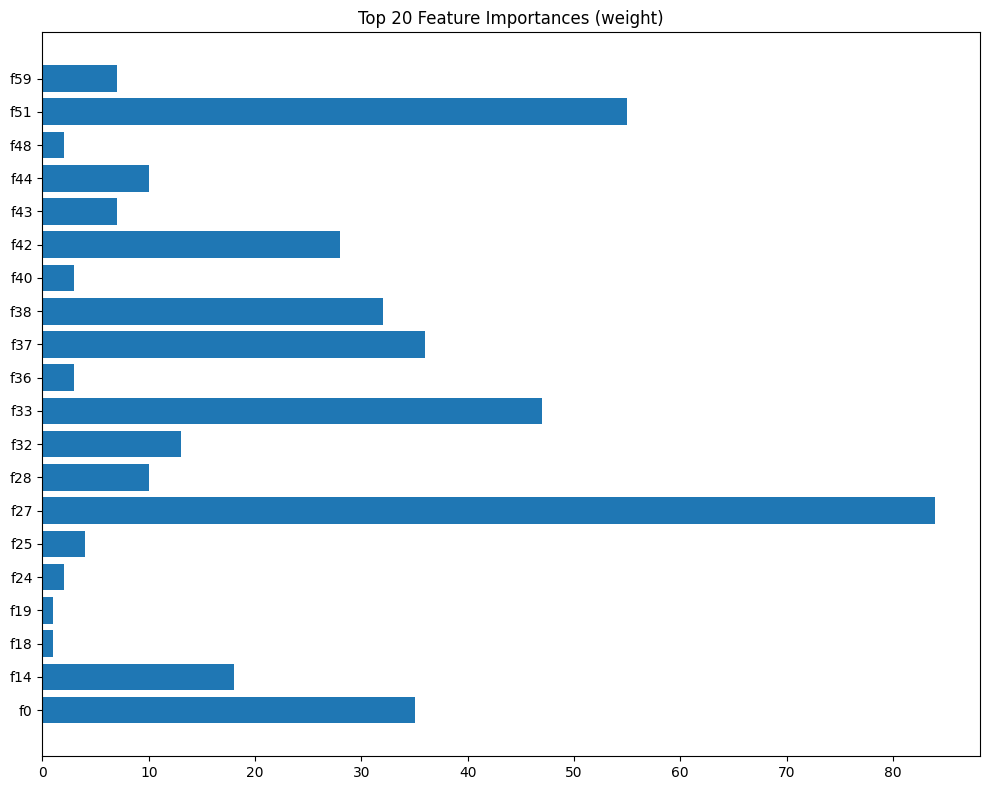

In [ ]:
import os

# =============================================================================
# 1. MOUNT DRIVE & SET MLFLOW
# =============================================================================
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"   # Must be set before any tracking
mlflow.set_tracking_uri("/content/drive/MyDrive/CustomerIntelligence/mlruns")
mlflow.set_experiment("CustomerIntelligence_Experiment")



# =============================================================================
# 7. TRAIN FINAL MODEL WITH BEST PARAMS & EVALUATE ON FULL TRAINING SET (CV)
# =============================================================================
best_model = Pipeline([
            ("combine",
         FunctionTransformer(combine_text, validate=False)),
    ('preprocessor', preprocessor),
    ('clf', xgb.XGBClassifier(**best_params, random_state=42, n_jobs=-1, eval_metric='mlogloss' if len(np.unique(y_train)) > 2 else 'logloss'))
])

# Evaluate with CV using multiple metrics
cv_scores = cross_validate(best_model, X_train, y_train, cv=StratifiedKFold(5, shuffle=True, random_state=42),
                           scoring=scoring_metrics, return_train_score=False, n_jobs=-1)

# Compute means and stds
results = {}
for key in cv_scores:
    if key.startswith('test_'):
        metric = key.replace('test_', '')
        results[metric] = (np.mean(cv_scores[key]), np.std(cv_scores[key]))

# =============================================================================
# 8. LOG EVERYTHING TO MLFLOW
# =============================================================================
with mlflow.start_run(run_name="XGBoost_Optuna_Best"):
    # Log best hyperparameters
    mlflow.log_params(best_params)

    # Log CV results
    for metric, (mean, std) in results.items():
        mlflow.log_metric(f"cv_{metric}_mean", mean)
        mlflow.log_metric(f"cv_{metric}_std", std)
        print(f"CV {metric}: {mean:.4f} ± {std:.4f}")

    # Log Optuna study metadata (optional)
    mlflow.log_param("optuna_trials", len(study.trials))
    mlflow.log_param("optuna_best_value", study.best_value)

    # Train final model on full training set (for production)
    best_model.fit(X_train, y_train)

    # Log the model
    #mlflow.xgboost.log_model(best_model, "xgboost_model")

    # Log confusion matrix and classification report on training data (optional)
    y_pred = best_model.predict(X_train)
    from sklearn.metrics import classification_report, confusion_matrix
    report = classification_report(y_train, y_pred)
    with open("/tmp/report.txt", "w") as f:
        f.write(report)
    mlflow.log_artifact("/tmp/report.txt", artifact_path="classification_report")

    # (Optional) log feature importance plot
    try:
        import matplotlib.pyplot as plt
        import xgboost as xgb
        booster = best_model.named_steps['clf'].get_booster()
        importance = booster.get_score(importance_type='weight')
        plt.figure(figsize=(10, 8))
        plt.barh(list(importance.keys())[:20], list(importance.values())[:20])
        plt.title('Top 20 Feature Importances (weight)')
        plt.tight_layout()
        plt.savefig("/tmp/feature_importance.png")
        mlflow.log_artifact("/tmp/feature_importance.png", artifact_path="plots")
    except:
        pass

print("="*50)
print("MLflow run completed. All artifacts stored in your Drive folder.")
print("Best CV log_loss: {:.4f}".format(study.best_value))
print("="*50)

#Training LightGBM

In [ ]:
# =============================================================================
# IMPORTS
# =============================================================================
import numpy as np
import pandas as pd
import optuna
from lightgbm import LGBMClassifier
from optuna.samplers import TPESampler

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer,LabelEncoder
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
    make_scorer
)

# =============================================================================
# PREPARE DATA
# =============================================================================

X = df.drop(columns=["Ticket Type"])
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["Ticket Type"])


# Hold-out test set (never used during Optuna tuning)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Determine evaluation metric once
eval_metric = "mlogloss" if len(np.unique(y)) > 2 else "logloss"
# =============================================================================
# SAFE LOG LOSS
# =============================================================================

logloss_scorer = make_scorer(
    log_loss,
    response_method="predict_proba",
    greater_is_better=False
)

# =============================================================================
# OPTUNA OBJECTIVE
# =============================================================================

def objective(trial):
    max_depth = trial.suggest_int(
        "max_depth",
        3,
        12
    )

    num_leaves = trial.suggest_int(
        "num_leaves",
        20,
        128
    )
    params = {

        "n_estimators": trial.suggest_int(
            "n_estimators", 100, 500, step=50
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.3, log=True
        ),

        "max_depth": max_depth,

        "num_leaves":num_leaves,

        "min_child_samples": trial.suggest_int(
            "min_child_samples", 5, 100
        ),

        "subsample": trial.suggest_float(
            "subsample", 0.6, 1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.6, 1.0
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha", 0.0, 5.0
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda", 0.0, 5.0
        ),

        "random_state": 42,

        "n_jobs": -1,

        "verbosity": -1,
        "objective": "multiclass",
        "num_class": len(np.unique(y)),
        "class_weight": "balanced",
    }

    pipeline = Pipeline([
        ("combine",
         FunctionTransformer(combine_text, validate=False)),

        ("preprocessor",
         preprocessor),

        ("clf",
         LGBMClassifier(**params))
    ])

    try:

      cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

      scores = cross_val_score(
          pipeline,
          X_train,
          y_train,
          scoring=logloss_scorer,
          cv=cv,
          n_jobs=1,
          error_score="raise"
      )

      mean_score = -np.mean(scores)

      if np.isnan(mean_score) or np.isinf(mean_score):
          return 1e6

      return mean_score

    except Exception as e:

      print(f"Trial failed: {e}")
      return 1e6
# =============================================================================
# CREATE STUDY
# =============================================================================
study = optuna.create_study(
    direction="minimize",
    sampler=TPESampler(seed=42),
    study_name="lightgbm_optuna_cv"
)

# =============================================================================
# RUN OPTIMIZATION
# =============================================================================

study.optimize(
    objective,
    n_trials=1,
    timeout=3600
)


# =============================================================================
# BEST PARAMETERS
# =============================================================================

best_params = study.best_params


print("=" * 60)
print("Best Hyperparameters")
print("=" * 60)

for k, v in best_params.items():
    print(f"{k}: {v}")

print("\nBest CV Log Loss:", study.best_value)



[I 2026-07-12 07:45:02,601] A new study created in memory with name: lightgbm_optuna_cv
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitte

Best Hyperparameters
max_depth: 3
num_leaves: 103
n_estimators: 200
learning_rate: 0.010056233324739785
min_child_samples: 99
subsample: 0.8224743651093012
colsample_bytree: 0.8486943885389154
reg_alpha: 0.2445306699308495
reg_lambda: 3.3831636312796705

Best CV Log Loss: 1.6156175093771494


CV score: -1.6152 ± 0.0020


2026/07/12 08:03:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


MLflow run completed. All artifacts stored in your Drive folder.
Best CV log_loss: 1.6156


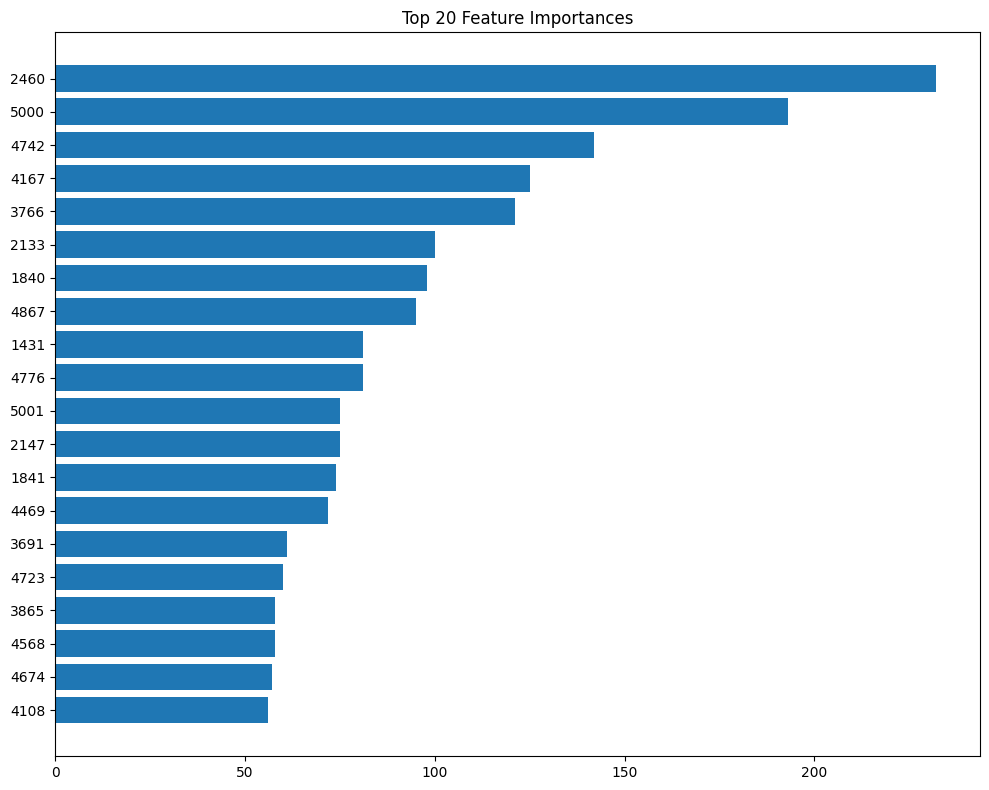

In [ ]:
import os
from sklearn.model_selection import StratifiedKFold, cross_validate,cross_val_score
import matplotlib.pyplot as plt

# =============================================================================
# 1. MOUNT DRIVE & SET MLFLOW
# =============================================================================
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"   # Must be set before any tracking
mlflow.set_tracking_uri("/content/drive/MyDrive/CustomerIntelligence/mlruns")
mlflow.set_experiment("CustomerIntelligence_Experiment")

best_params.update({

    "random_state": 42,

    "n_jobs": -1,

    "verbosity": -1
})


# =============================================================================
# 7. TRAIN FINAL MODEL WITH BEST PARAMS & EVALUATE ON FULL TRAINING SET (CV)
# =============================================================================
best_model = Pipeline([

    ("combine",
     FunctionTransformer(combine_text, validate=False)),

    ("preprocessor",
     preprocessor),

    ("clf",
     LGBMClassifier(**best_params))

])


# Compute means and stds
results = {}
for key in cv_scores:
    if key.startswith('test_'):
        metric = key.replace('test_', '')
        results[metric] = (np.mean(cv_scores[key]), np.std(cv_scores[key]))

# =============================================================================
# 8. LOG EVERYTHING TO MLFLOW
# =============================================================================
with mlflow.start_run(run_name="LightGBM_Optuna_Best"):
    # Log best hyperparameters
    mlflow.log_params(best_params)

    # Log CV results
    for metric, (mean, std) in results.items():
        mlflow.log_metric(f"cv_{metric}_mean", mean)
        mlflow.log_metric(f"cv_{metric}_std", std)
        print(f"CV {metric}: {mean:.4f} ± {std:.4f}")

    # Log Optuna study metadata (optional)
    mlflow.log_param("optuna_trials", len(study.trials))
    mlflow.log_param("optuna_best_value", study.best_value)

    # Train final model on full training set (for production)
    best_model.fit(X_train, y_train)

    import mlflow.lightgbm

    mlflow.lightgbm.log_model(
          best_model.named_steps["clf"],
          artifact_path="lightgbm_model"
    )

    # Log confusion matrix and classification report on training data (optional)
    y_pred = best_model.predict(X_test)
    from sklearn.metrics import classification_report, confusion_matrix
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

    report = classification_report(y_test, y_pred)
    with open("/tmp/report.txt", "w") as f:
        f.write(report)
    mlflow.log_artifact("/tmp/report.txt", artifact_path="classification_report")

    cm = confusion_matrix(y_test, y_pred)

    # Plot confusion matrix
    fig, ax = plt.subplots(figsize=(8, 6))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder.classes_   # Remove this line if not using LabelEncoder
    )

    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)

    plt.title("Confusion Matrix")
    plt.tight_layout()

    # Save figure
    cm_path = "/tmp/confusion_matrix.png"
    plt.savefig(cm_path, dpi=300)
    plt.close(fig)

    # Log to MLflow
    mlflow.log_artifact(cm_path, artifact_path="plots")

    # (Optional) log feature importance plot
    try:


      model = best_model.named_steps["clf"]

      importance = model.feature_importances_

      top_n = 20

      idx = np.argsort(importance)[-top_n:]

      plt.figure(figsize=(10,8))
      plt.barh(range(len(idx)), importance[idx])
      plt.yticks(range(len(idx)), idx)
      plt.title("Top 20 Feature Importances")
      plt.tight_layout()

      plt.savefig("/tmp/feature_importance.png")

      mlflow.log_artifact(
          "/tmp/feature_importance.png",
          artifact_path="plots"
      )

    except Exception as e:
      print(e)

print("="*50)
print("MLflow run completed. All artifacts stored in your Drive folder.")
print("Best CV log_loss: {:.4f}".format(study.best_value))
print("="*50)